# Modelado de Demanda Energética — Área OCC
**Variable objetivo:** `Estimacion de Demanda por Balance (MWh)`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')


/Users/sayuriherreramoreno/.pyenv/versions/ml-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Carga y filtrado de datos

In [7]:
df_area = pd.read_csv('datos_occ.csv')
df_area['Timestamp'] = pd.to_datetime(df_area['Timestamp'])

print(f'Registros OCC: {df_area.shape[0]:,}')
print(f'Periodo: {df_area["Timestamp"].min()} → {df_area["Timestamp"].max()}')
df_area.head()

Registros OCC: 41,541
Periodo: 2020-01-01 00:00:00 → 2024-09-30 23:00:00


,Sistema,Area,Generacion (MWh),Importacion Total (MWh),Exportacion Total (MWh),Intercambio neto entre Gerencias (MWh),Estimacion de Demanda por Balance (MWh),Pronostico (MWh),Timestamp,fecha,hora,anio,mes,dia_semana
0,SIN,OCC,3269.58909,0.0,0.0,2389.952,5659.54109,5915.758,2020-01-01 00:00:00,2020-01-01,0,2020,1,Wednesday
1,SIN,OCC,3251.92533,0.0,0.0,2223.747,5475.67233,5752.314,2020-01-01 01:00:00,2020-01-01,1,2020,1,Wednesday
2,SIN,OCC,3324.54144,0.0,0.0,1931.442,5255.98344,5566.535,2020-01-01 02:00:00,2020-01-01,2,2020,1,Wednesday
3,SIN,OCC,3318.09918,0.0,0.0,1759.341,5077.44018,5385.318,2020-01-01 03:00:00,2020-01-01,3,2020,1,Wednesday
4,SIN,OCC,3403.84801,0.0,0.0,1525.132,4928.98001,5288.158,2020-01-01 04:00:00,2020-01-01,4,2020,1,Wednesday


## Ingeniería de carcactristicas

Se seleccionan las variables:

**Variables temporales** — muestran los patrones de hora, día y mes identificados en el EDA.

**Lag features** — valores pasados de demanda y generación.

- `lag_1h`: demanda hace 1 hora 
- `lag_24h`: demanda hace 24 horas 
- `lag_168h`: demanda hace 168 horas (7 días) 
- `gen_lag_1h / gen_lag_24h`: generación pasada

In [10]:
target = 'Estimacion de Demanda por Balance (MWh)'

# Variables temporales
df_area['hora']       = df_area['Timestamp'].dt.hour
df_area['dia_semana'] = df_area['Timestamp'].dt.dayofweek   # 0 = lunes, 6 = domingo
df_area['mes']        = df_area['Timestamp'].dt.month
df_area['anio']       = df_area['Timestamp'].dt.year
df_area['dia_anio']   = df_area['Timestamp'].dt.dayofyear

# Lag features de demanda
df_area['lag_1h']   = df_area[target].shift(1)
df_area['lag_24h']  = df_area[target].shift(24)
df_area['lag_168h'] = df_area[target].shift(168)

# Lag features de generación (valores pasados — no el valor simultáneo)
df_area['gen_lag_1h']  = df_area['Generacion (MWh)'].shift(1)
df_area['gen_lag_24h'] = df_area['Generacion (MWh)'].shift(24)

# Eliminar filas con NaN generados por los lags
df_area = df_area.dropna().reset_index(drop=True)

print(f'Registros al crearlags: {df_area.shape[0]:,}')
print(f'Características disponibles: {df_area.shape[1]}')

Registros al crearlags: 41,037
Características disponibles: 20


## Definición de features y split temporal

> Considerar que el split debe respetar el orden cronológico para evitar que el modelo "vea el futuro" durante el entrenamiento por lo que no se va a dividir aleatoriamente.

In [11]:
features = [
    # Generación pasada
    'Generacion (MWh)',   # valor actual de generación (no es un lag, pero es una variable importante)
    'gen_lag_1h',
    'gen_lag_24h',
    # Variables temporales
    'hora', 'dia_semana', 'mes', 'anio', 'dia_anio',
    # Lags de demanda
    'lag_1h', 'lag_24h', 'lag_168h'
]

X = df_area[features]
y = df_area[target]

# Split 80% entrenamiento / 20% prueba — por orden temporal
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Entrenamiento: {len(X_train):,} registros')
print(f'  Periodo: {df_area["Timestamp"].iloc[0]} → {df_area["Timestamp"].iloc[split-1]}')
print(f'Prueba:        {len(X_test):,} registros')
print(f'  Periodo: {df_area["Timestamp"].iloc[split]} → {df_area["Timestamp"].iloc[-1]}')


Entrenamiento: 32,829 registros
  Periodo: 2020-01-22 00:00:00 → 2023-10-24 23:00:00
Prueba:        8,208 registros
  Periodo: 2023-10-25 00:00:00 → 2024-09-30 23:00:00


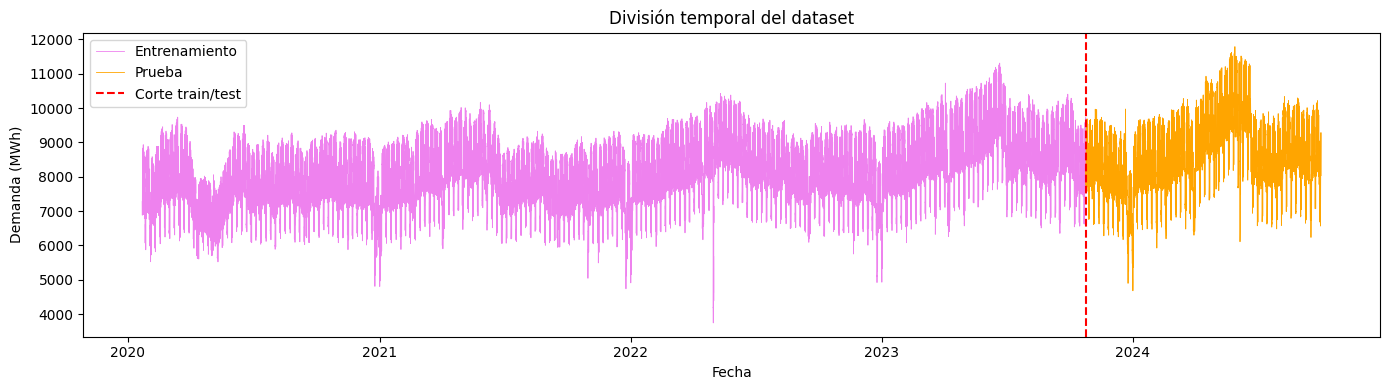

In [13]:
#Visualización de la división temporal del dataset
plt.figure(figsize=(14, 4))
plt.plot(df_area['Timestamp'].iloc[:split], y_train, label='Entrenamiento', color='violet', linewidth=0.6)
plt.plot(df_area['Timestamp'].iloc[split:], y_test,  label='Prueba',        color='orange',    linewidth=0.6)
plt.axvline(df_area['Timestamp'].iloc[split], color='red', linestyle='--', label='Corte train/test')
plt.title('División temporal del dataset')
plt.xlabel('Fecha')
plt.ylabel('Demanda (MWh)')
plt.legend()
plt.tight_layout()
plt.show()

## Métricas a considerar

Se usarán tres métricas para evaluar todos los modelos:
- **MAE**
- **RMSE** 
- **MAPE** (Solo será para elegir un modelo)

In [ ]:
def evaluar_modelo(nombre, y_true, y_pred):
    """Calcula MAE, RMSE y MAPE e imprime un resumen."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100
    print(f'{nombre:<35} MAE: {mae:>8.2f} MWh  |  RMSE: {rmse:>8.2f}  |  MAPE: {mape:>5.2f}%')
    return {'Modelo': nombre, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

resultados = []  # Lista para almacenar resultados de cada modelo

## 6. Baseline 

Antes de entrenar un modelo, se establece una **línea base** usando el pronóstico oficial que ya viene en el dataset. Cualquier modelo que hagamos o probemos debemos hacer que la supere para justificar su uso y como se tiene una varible de Pronostico (MWh) se puede implementar.

In [15]:
pronostico_test = df_area['Pronostico (MWh)'].iloc[split:].values
r = evaluar_modelo('Baseline', y_test.values, pronostico_test)
resultados.append(r)

Baseline                            MAE:   353.12 MWh  |  RMSE:   424.23  |  MAPE:  4.18%


##  Modelo 1 — Random Forest

In [16]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r = evaluar_modelo('Random Forest', y_test.values, y_pred_rf)
resultados.append(r)

Random Forest                       MAE:    78.04 MWh  |  RMSE:   123.35  |  MAPE:  0.90%


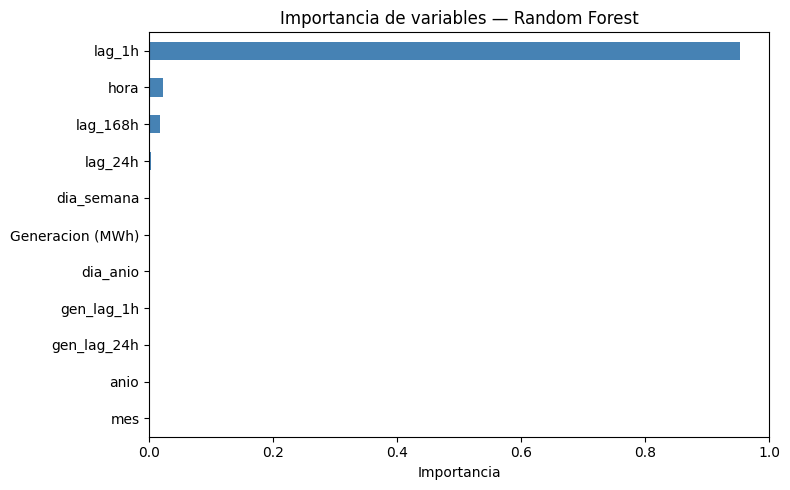

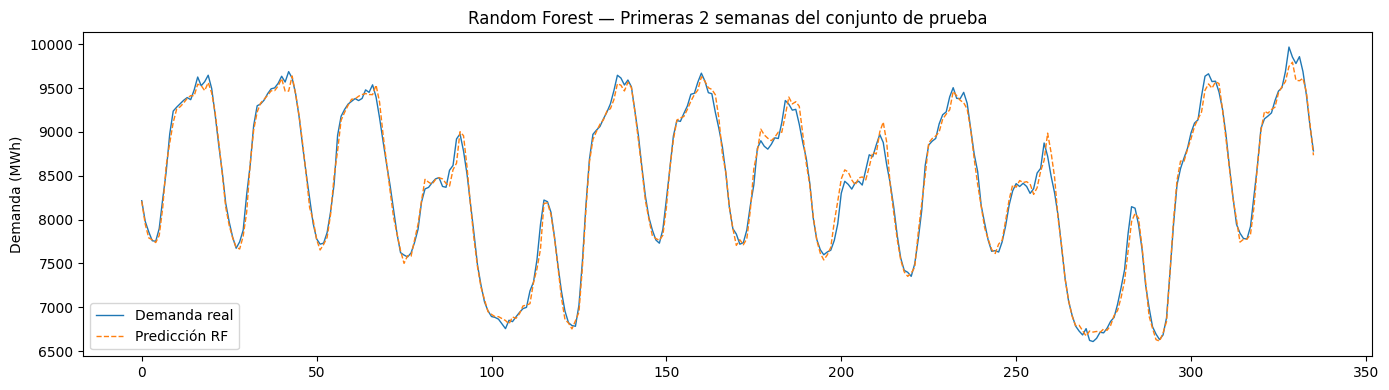

In [17]:
# Random Forest visualización

# Importancia de variables 
feat_imp_rf = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp_rf.plot(kind='barh', color='steelblue')
plt.title('Importancia de variables — Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# Predicción vs real 
n_vis = 24 * 14
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:n_vis],    label='Demanda real', linewidth=1)
plt.plot(y_pred_rf[:n_vis],        label='Predicción RF', linewidth=1, linestyle='--')
plt.title('Random Forest — Primeras 2 semanas del conjunto de prueba')
plt.ylabel('Demanda (MWh)')
plt.legend()
plt.tight_layout()
plt.show()

## Modelo 2 — XGBoost

In [18]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred_xgb = xgb.predict(X_test)

r = evaluar_modelo('XGBoost', y_test.values, y_pred_xgb)
resultados.append(r)

XGBoost                             MAE:    74.44 MWh  |  RMSE:   123.92  |  MAPE:  0.86%


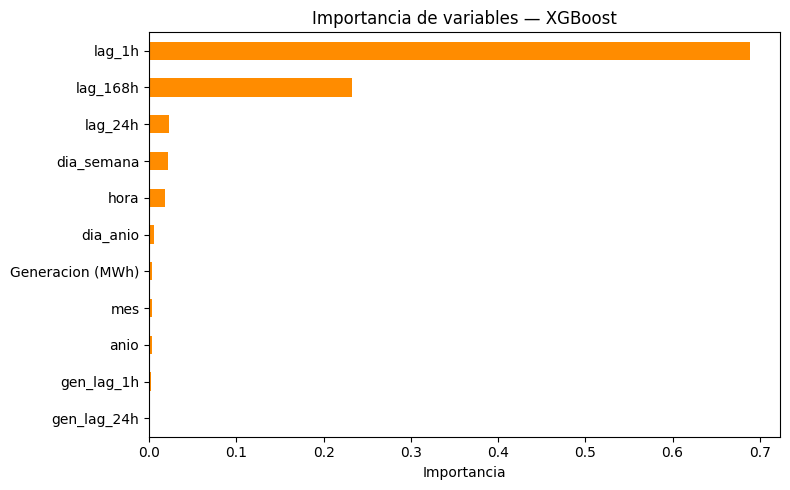

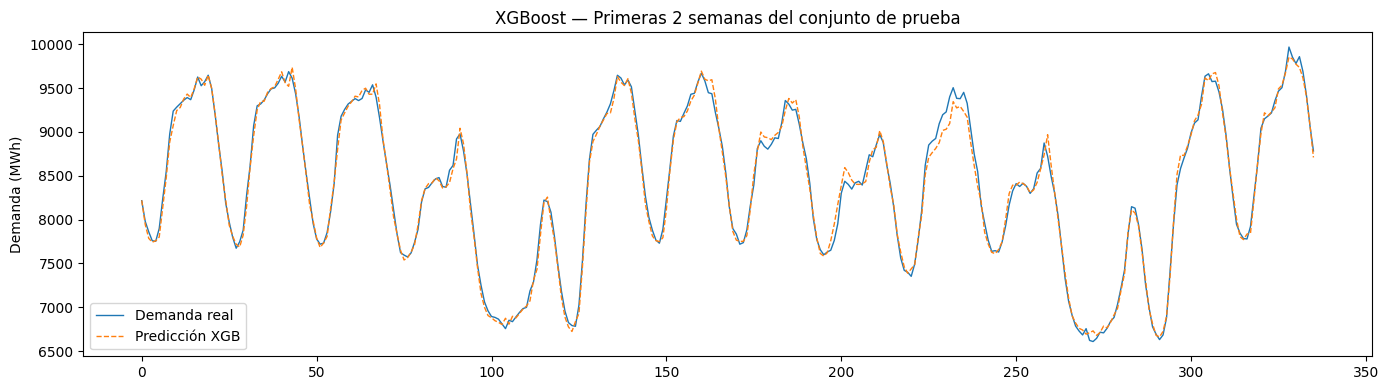

In [ ]:
# XGBoost visualización

# Importancia de variables — XGBoost
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp_xgb.plot(kind='barh', color='coral')
plt.title('Importancia de variables — XGBoost')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# Predicción vs real
n_vis = 24 * 14
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:n_vis],   label='Demanda real',    linewidth=1)
plt.plot(y_pred_xgb[:n_vis],      label='Predicción XGB',  linewidth=1, linestyle='--')
plt.title('XGBoost — Primeras 2 semanas del conjunto de prueba')
plt.ylabel('Demanda (MWh)')
plt.legend()
plt.tight_layout()
plt.show()

## Modelo 3 — Prophet

Prophet es un modelo de series de tiempo desarrollado por Meta. Trabaja directamente con el tiempo como variable, detecta automáticamente estacionalidad diaria, semanal y anual. No usa los features de generación — trabaja solo con la señal temporal de la demanda.

Prophet requiere columnas 'ds' (fechas) e 'y' (variable objetivo)

Se usa `seasonality_mode='multiplicative'` porque en datos de energía la amplitud de los ciclos varía con el nivel general de la demanda.

In [27]:
# Prophet requiere columnas 'ds' (fecha) e 'y' (variable objetivo)
df_prophet = df_area[['Timestamp', target]].rename(columns={'Timestamp': 'ds', target: 'y'})

# Split temporal usando el mismo punto de corte
fecha_corte = df_area['Timestamp'].iloc[split]
train_p = df_prophet[df_prophet['ds'] < fecha_corte]
test_p  = df_prophet[df_prophet['ds'] >= fecha_corte]

# Entrenar
model_p = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)
model_p.fit(train_p)

# Predecir
future   = model_p.make_future_dataframe(periods=len(test_p), freq='h')
forecast = model_p.predict(future)
y_pred_p = forecast.tail(len(test_p))['yhat'].values

r = evaluar_modelo('Prophet', test_p['y'].values, y_pred_p)
resultados.append(r)

00:55:16 - cmdstanpy - INFO - Chain [1] start processing
00:55:25 - cmdstanpy - INFO - Chain [1] done processing


Prophet                             MAE:   484.59 MWh  |  RMSE:   617.12  |  MAPE:  5.71%


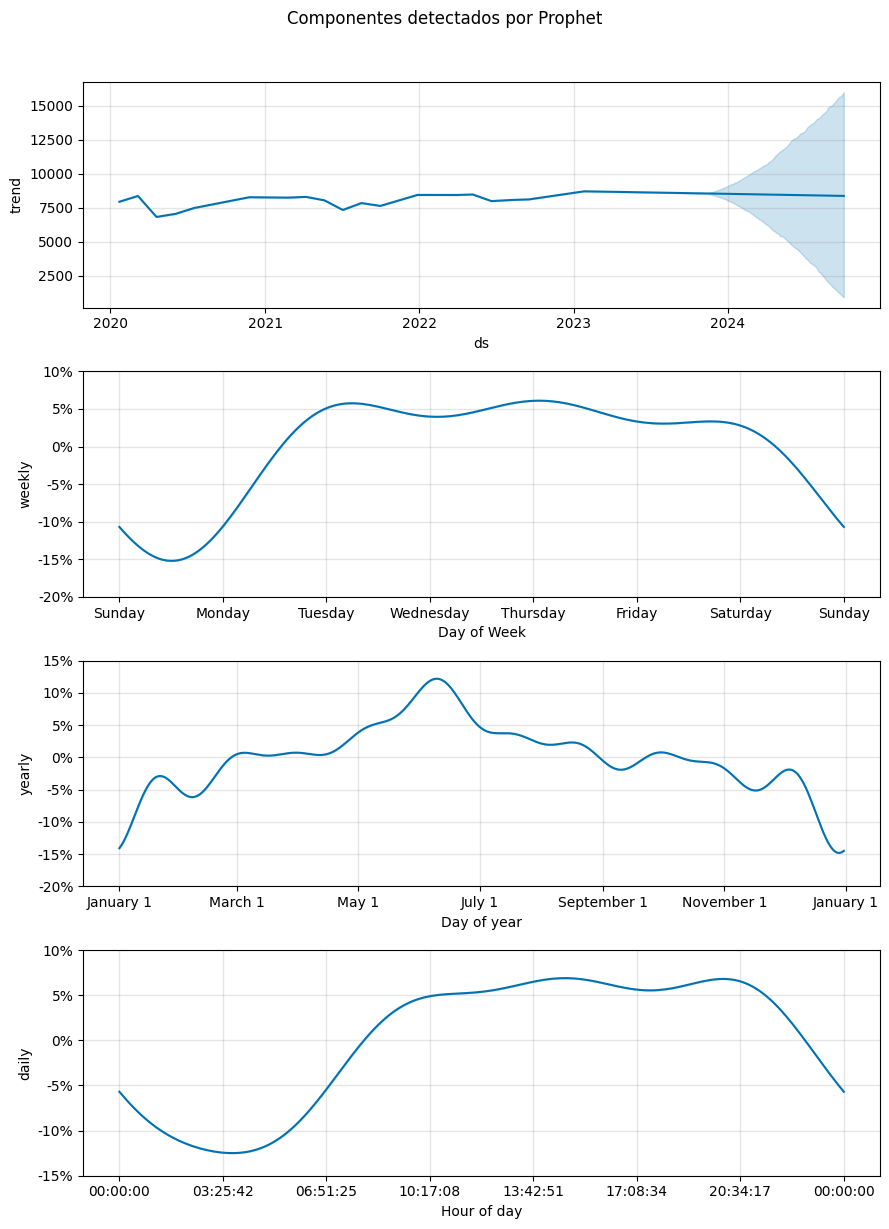

In [21]:
# Componentes del modelo Prophet (tendencia + estacionalidades)
model_p.plot_components(forecast)
plt.suptitle('Componentes detectados por Prophet', y=1.02)
plt.tight_layout()
plt.show()

## Comparación final de modelos

In [ ]:
# Tabla de resultados
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('MAPE')
print('\n COMPARACIÓN DE MODELOS ')
print(df_resultados.to_string(index=False))


===== COMPARACIÓN DE MODELOS =====
       Modelo    MAE   RMSE  MAPE
      XGBoost  74.44 123.92  0.86
Random Forest  78.04 123.35  0.90
     Baseline 353.12 424.23  4.18
      Prophet 484.59 617.12  5.71


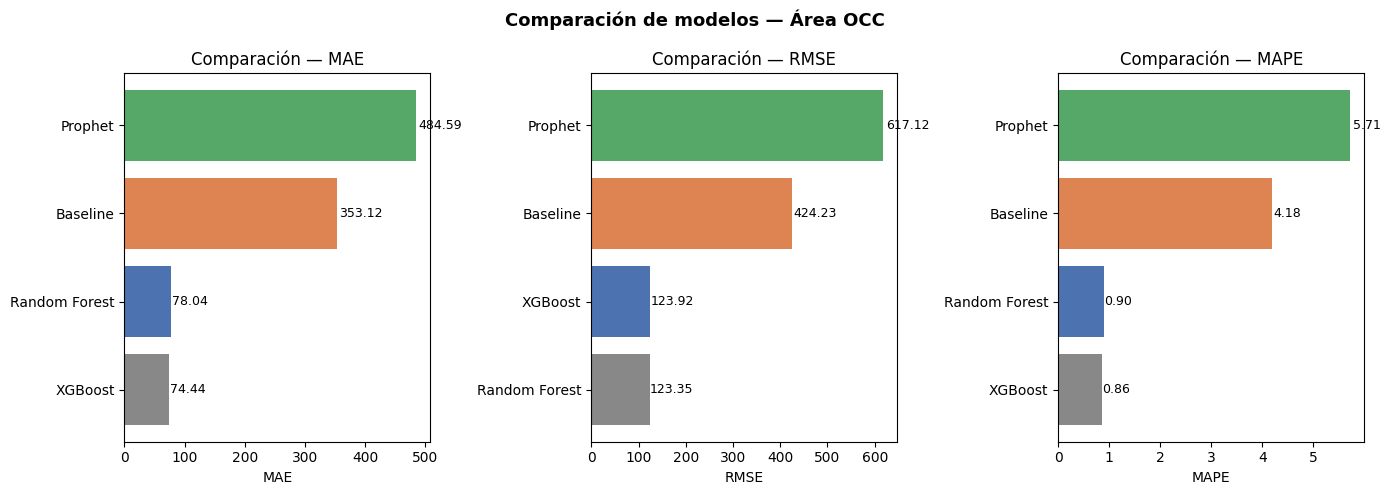

In [23]:
# Gráfica de comparación — MAPE
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colores = ['#888888', '#4C72B0', '#DD8452', '#55A868']

for ax, metrica in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    df_plot = df_resultados.sort_values(metrica)
    bars = ax.barh(df_plot['Modelo'], df_plot[metrica], color=colores[:len(df_plot)])
    ax.set_title(f'Comparación — {metrica}')
    ax.set_xlabel(metrica)
    # Etiquetas
    for bar, val in zip(bars, df_plot[metrica]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('Comparación de modelos — Área OCC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

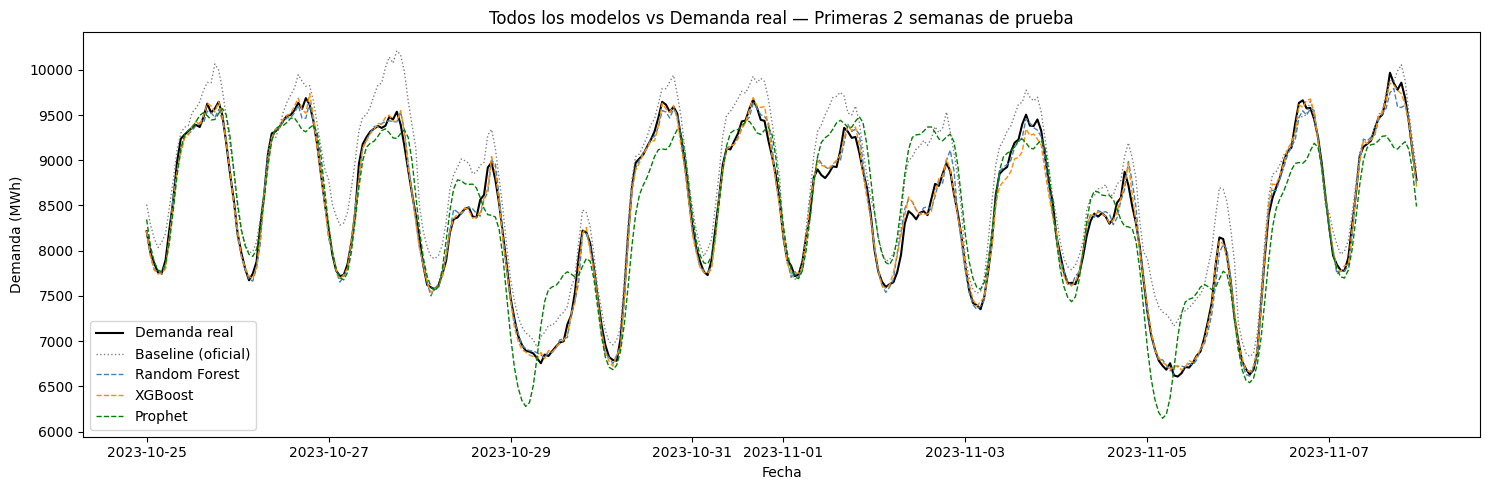

In [24]:
# Visualización conjunta — predicciones de todos los modelos vs real
# Se muestran las primeras 2 semanas del conjunto de prueba para claridad visual
n_vis = 24 * 14
fechas_test = df_area['Timestamp'].iloc[split:split + n_vis]

plt.figure(figsize=(15, 5))
plt.plot(fechas_test, y_test.values[:n_vis],       label='Demanda real',       linewidth=1.5, color='black')
plt.plot(fechas_test, pronostico_test[:n_vis],      label='Baseline (oficial)', linewidth=1,   color='gray',       linestyle=':')
plt.plot(fechas_test, y_pred_rf[:n_vis],            label='Random Forest',      linewidth=1,   color='steelblue',  linestyle='--')
plt.plot(fechas_test, y_pred_xgb[:n_vis],           label='XGBoost',            linewidth=1,   color='darkorange', linestyle='--')
plt.plot(fechas_test, y_pred_p[:n_vis],             label='Prophet',            linewidth=1,   color='green',      linestyle='--')

plt.title('Todos los modelos vs Demanda real — Primeras 2 semanas de prueba')
plt.xlabel('Fecha')
plt.ylabel('Demanda (MWh)')
plt.legend()
plt.tight_layout()
plt.show()

El modelo XGBoost obtuvo el mejor desempeño con un MAPE de 0.86%, superando al pronóstico oficial del dataset en un 79.4%. El modelo Random Forest obtuvo resultados similares (MAPE 0.90%), lo que sugiere que la ingeniería de features — particularmente los lag features de demanda y generación — fue el factor determinante del rendimiento, dado que Prophet, al no contar con estas variables, obtuvo el peor resultado a pesar de estar diseñado específicamente para series de tiempo.

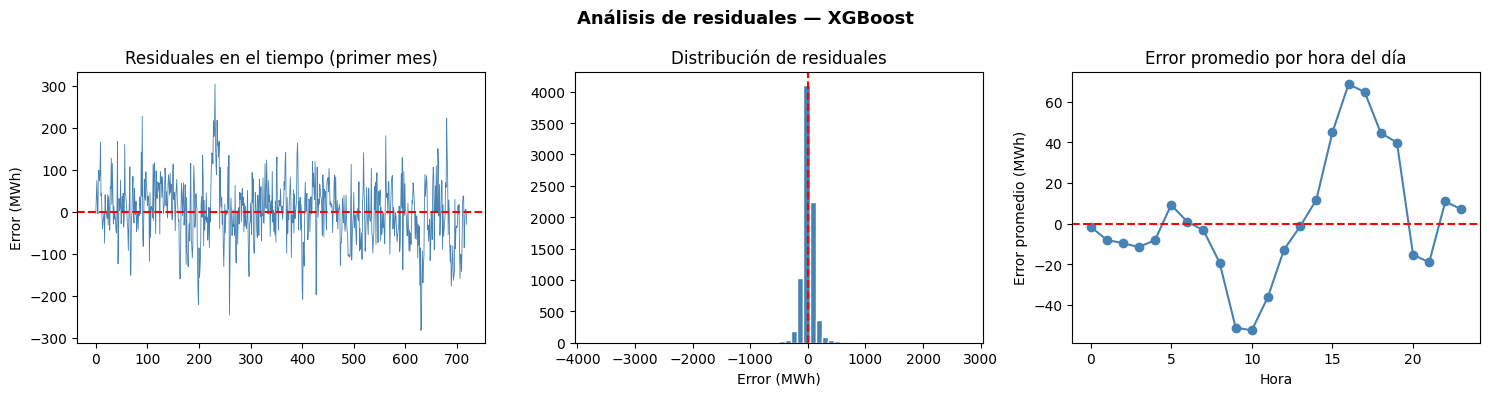

Error promedio (sesgo): 2.22 MWh
Desviación estándar:    123.90 MWh


In [ ]:
mejor_pred   = y_pred_xgb 
mejor_nombre = 'XGBoost'     

residuales = y_test.values - mejor_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuales en el tiempo
axes[0].plot(residuales[:24*30], linewidth=0.6, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuales en el tiempo (primer mes)')
axes[0].set_ylabel('Error (MWh)')

# Histograma de residuales
axes[1].hist(residuales, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de residuales')
axes[1].set_xlabel('Error (MWh)')

# Residuales por hora del día
df_res = pd.DataFrame({'residual': residuales, 'hora': df_area['hora'].iloc[split:].values})
df_res.groupby('hora')['residual'].mean().plot(ax=axes[2], marker='o', color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Error promedio por hora del día')
axes[2].set_xlabel('Hora')
axes[2].set_ylabel('Error promedio (MWh)')

plt.suptitle(f'Análisis de residuales — {mejor_nombre}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Error promedio (sesgo): {residuales.mean():.2f} MWh')
print(f'Desviación estándar:    {residuales.std():.2f} MWh')

Colocar coeficientes de determinacion